# SWM mapping in the AHEAD brain

### Libraries

In [1]:
import os
import glob
import nibabel as nb
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
import numpy as np
import seaborn as sns
import pandas as pd
import cmocean
import matplotlib.pyplot as plt
import matplotlib as mpl
from brainspace.datasets import load_mask

### Load surfaces and masks

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
mask_surf = mask_5k != 0
#mask_surf = mask_32k != 0

### Functions

## F1: Surface-based intensity smoothing and processing for Ahead brain

In [3]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            inf_lh, inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

## F2: Functions for loading data

In [9]:
def load_SWM_group_5k(surf):
    """
    Load Superficial White Matter (SWM) intensity profiles for different surface types.
    
    Parameters:
    surf (str): Surface type ('orig', 'Bielschowsky', or 'Parvalbumin')
    
    Returns:
    tuple: Mean intensity map and smoothed intensity profile matrix.
    """
    # Define directory paths based on surface type
    base_dir = "/host/percy/local_raid/youngeun/sub-AHEAD/sub-122017/"
    swm_dirs = {
        'orig': f"{base_dir}SWM_50map-Bielschowsky_HR",
        'Bielschowsky': f"{base_dir}FS_SWM/SWM_50map-fsLR-Bielschowsky_HR",
        'Parvalbumin': f"{base_dir}FS_SWM/SWM_50map-fsLR-Parvalbumin_HR"
    }
    dir_surf = swm_dirs.get(surf)
    if not dir_surf:
        raise ValueError("Invalid surface type. Choose from 'orig', 'Bielschowsky', or 'Parvalbumin'.")
    
    # Load file paths
    files_lh = sorted(glob.glob(f"{dir_surf}/Ahead_brain_122017_lh_surf-{surf}-fsLR5k-swm*mm.func.gii"))
    files_rh = sorted(glob.glob(f"{dir_surf}/Ahead_brain_122017_rh_surf-{surf}-fsLR5k-swm*mm.func.gii"))
    
    # Load SWM data
    Nqmri = np.concatenate((nb.load(files_lh[0]).darrays[0].data, nb.load(files_rh[0]).darrays[0].data)).shape[0]
    surf_map = np.empty((len(files_lh), Nqmri), dtype=float)
    
    for i, _ in enumerate(files_lh):
        surf_map[i, :] = np.hstack((
            nb.load(files_lh[i]).darrays[0].data,
            nb.load(files_rh[i]).darrays[0].data
        ))
    
    # Smooth intensity profiles
    profile_smooth = smooth_intensities(surf_map)
    #profile_smooth[:, mask_5k == False] = np.nan
    
    # Compute mean intensity map
    map_mean = np.nanmean(profile_smooth, axis=0)
    print(f"Number of surfaces: {surf_map.shape[0]}")
    
    return map_mean, profile_smooth

def load_GM_group_5k(surf):
    """
    Load Grey Matter (GM) intensity profiles for different surface types.
    
    Parameters:
    surf (str): Surface type ('orig', 'Bielschowsky', or 'Parvalbumin')
    
    Returns:
    tuple: Mean intensity map and smoothed intensity profile matrix.
    """
    # Define directory paths based on surface type
    #base_dir = "/host/percy/local_raid/youngeun/sub-AHEAD/sub-122017/"
    base_dir="/host/percy/local_raid/youngeun/sub-AHEAD/sub-122017/correct_maps/"
    gm_dirs = {
        'orig': f"{base_dir}GM_50map-Bielschowsky",
        'Bielschowsky': f"{base_dir}GM_50map-fsLR-Bielschowsky",
        'Parvalbumin': f"{base_dir}GM_50map-fsLR5k-Parvalbumin"
    }
    dir_surf = gm_dirs.get(surf)
    if not dir_surf:
        raise ValueError("Invalid surface type. Choose from 'orig', 'Bielschowsky', or 'Parvalbumin'.")
    
    # Load file paths
    files_lh = sorted(glob.glob(f"{dir_surf}/Ahead_brain_122017_lh_surf-{surf}-fsLR5k-gm*.func.gii"))
    files_rh = sorted(glob.glob(f"{dir_surf}/Ahead_brain_122017_rh_surf-{surf}-fsLR5k-gm*.func.gii"))
    
    # Load GM data
    Nqmri = np.concatenate((nb.load(files_lh[0]).darrays[0].data, nb.load(files_rh[0]).darrays[0].data)).shape[0]
    surf_map = np.empty((len(files_lh), Nqmri), dtype=float)
    
    for i, _ in enumerate(files_lh):
        surf_map[i, :] = np.hstack((
            nb.load(files_lh[i]).darrays[0].data,
            nb.load(files_rh[i]).darrays[0].data
        ))
    
    # Smooth intensity profiles
    #profile_smooth = smooth_intensities(surf_map)
    #profile_smooth[:, mask_5k == False] = np.nan
    
    # Compute mean intensity map
    map_mean = np.nanmean(surf_map, axis=0)
    print(f"Number of surfaces: {surf_map.shape[0]}")
    
    return map_mean, surf_map

## F3: Ridge plot for visualizing histological intensity distributions

In [5]:
## # Function: Generate a ridge plot to visualize intensity distributions across subjects

def plot_ridgeplot(matrix, matrix_df=None, Cmap='rocket', Range=(2.5, 4.5), Xlab="AHEAD", save_path=None, title=None):
    '''
    Creates a ridge plot (stacked density plots) to visualize intensity distributions across different subjects.
    
    Parameters:
    -----------
    matrix : np.array
        Input intensity profile matrix, where each row represents a subject.
    matrix_df : list, optional
        Labels corresponding to each row of the matrix (e.g., subject IDs).
    Cmap : str, optional
        Colormap for the visualization (default: 'rocket').
    Range : tuple, optional
        X-axis limits (default: (2.5, 4.5)).
    Xlab : str, optional
        X-axis label (default: "flair").
    save_path : str, optional
        If provided, saves the figure to the specified path instead of displaying it.
    title : str, optional
        Title for the entire plot.
    '''
    
    # Flatten intensity matrix and prepare subject and ID labels
    ai = matrix.flatten()
    subject = np.array([])
    id_x = np.array([])
    
    for i in range(matrix.shape[0]):
        label = np.array([str(i+1) for j in range(matrix.shape[1])])
        subject = np.concatenate((subject, label))
        id_label = np.array([matrix_df[i] for j in range(matrix.shape[1])])
        id_x = np.concatenate((id_x, id_label))
    
    # Create DataFrame for plotting
    df = pd.DataFrame({
        'feature': ai,
        'subject': subject,
        'id_x': id_x
    })
    
    # Initialize figure and axes for ridge plot
    #f, axs = plt.subplots(nrows=matrix.shape[0], figsize=(3.468504*2.5, 2.220472*3.5), sharex=True, sharey=True)
    f, axs = plt.subplots(nrows=matrix.shape[0], figsize=(3.468504*2.5, 2.220472*5), sharex=True, sharey=True)
    f.set_facecolor('none')
    
    x = np.linspace(Range[0], Range[1], 100)  # Define x-axis range
    
    for i, ax in enumerate(axs, 1):
        # Plot density estimation
        sns.kdeplot(df[df["subject"]==str(i)]['feature'],
                    fill=True,
                    color="w",
                    alpha=0.25,
                    linewidth=1.5,
                    legend=False,
                    ax=ax)
        
        ax.set_xlim(Range[0], Range[1])
        
        # Overlay colormap
        im = ax.imshow(np.vstack([x, x]),
                       cmap=Cmap,
                       aspect="auto",
                       extent=[*ax.get_xlim(), *ax.get_ylim()]
                      )
        
        # Clip colormap to density shape
        path = ax.collections[0].get_paths()[0]
        patch = mpl.patches.PathPatch(path, transform=ax.transData)
        im.set_clip_path(patch)
        
        # Remove unnecessary plot borders
        ax.spines[['left','right','bottom','top']].set_visible(False)
        
        # Hide x-axis ticks except for the last plot
        if i != matrix.shape[0]:
            ax.tick_params(axis="x", length=0)
        else:
            ax.set_xlabel(Xlab)
        
        ax.set_yticks([])
        ax.set_ylabel("")
        ax.axhline(0, color="black")
        ax.set_facecolor("none")
    
    # Add subject labels to the left side of each plot
    for i, ax in enumerate(axs):
        if i == matrix.shape[0] - 1:
            ax.set_xticks([Range[0], Range[1]])  # Set x-axis ticks for the bottom plot
        else:
            ax.set_xticks([])  # Remove x-axis ticks from other plots
        ax.text(0.05, 0.01, matrix_df[i], transform=ax.transAxes, fontsize=10, color='black', ha='left', va='bottom')
    
    plt.subplots_adjust(hspace=-0.8)  # Adjust spacing between plots
    
    # Add title if provided
    if title:
        plt.suptitle(title, y=0.99, fontsize=16)
    
    # Save or display the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

## F4: Plot intensity profiles

In [6]:
def plot_filtered_pcolormesh(data, mask, color_range=(350,650), figsize=(15, 8), cmap='gray'):
    """
    Plot a filtered pcolormesh after removing NaN-containing vertices.

    Parameters:
        data (ndarray): 2D array representing the data to be plotted.
        mask (ndarray): Boolean mask indicating valid vertices (True = valid, False = remove).
        color_range (tuple): Range for colormap scaling (vmin, vmax).
        figsize (tuple): Figure size (width, height).
        cmap (str): Colormap for visualization.
    """

    # Mask out invalid vertices
    data[:, mask == False] = np.nan
    valid_vertices = ~np.isnan(data).any(axis=0)
    filtered_data = data[:, valid_vertices]
    filtered_data = filtered_data[::-1, :]

    # Create figure
    plt.figure(figsize=figsize)

    # Plot the pcolormesh
    pcm = plt.pcolormesh(filtered_data, cmap=cmap, shading='auto', vmin=color_range[0], vmax=color_range[1])

    # Remove axis labels
    plt.xticks([])
    plt.yticks([])

    # Add colorbar
    plt.colorbar(pcm)

    # Show plot
    plt.show()

## Plot mean intensity

### Bielschowsky

In [8]:
bfmean5k, bfmap5k = load_SWM_group_5k(surf='Bielschowsky')

Number of surfaces: 51


In [26]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD-B_SWM_IPs_5k.npy', bfmap5k)

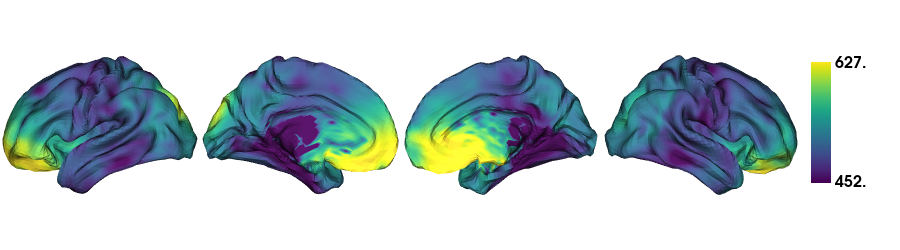

In [9]:
# Plot average SWM surfaces
bcrange=(np.quantile(bfmean5k[mask_5k==True], 0.05), np.quantile(bfmean5k[mask_5k==True], 0.99))
plot_hemispheres(f5k_lh, f5k_rh, array_name=bfmean5k, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=bcrange)

/tmp/ipykernel_1226634/727554129.py:41: RuntimeWarning: Mean of empty slice
  map_mean = np.nanmean(profile_smooth, axis=0)


Number of surfaces: 51


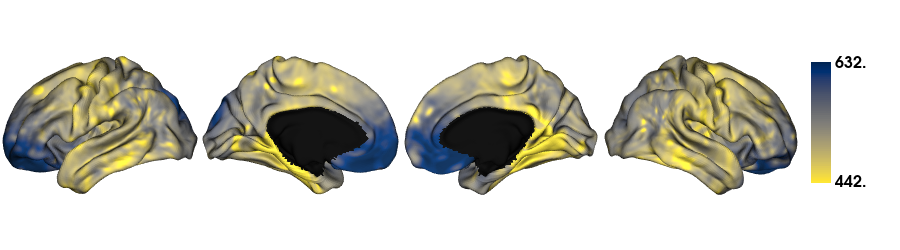

In [11]:
bfmean32k, bfmap32k = load_SWM_group_32k(surf='Bielschowsky')
# Plot average SWM surfaces
bcrange=(np.quantile(bfmean32k[mask_32k==True], 0.05), np.quantile(bfmean32k[mask_32k==True], 0.99))
plot_hemispheres(f32k_lh, f32k_rh, array_name=bfmean32k, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=bcrange)

### Parvalbumin

In [22]:
pfmean5k, pfmap5k = load_SWM_group_5k(surf='Parvalbumin')

Number of surfaces: 51


/tmp/ipykernel_3098203/887157362.py:41: RuntimeWarning: Mean of empty slice
  map_mean = np.nanmean(profile_smooth, axis=0)


In [10]:
pfmean5k, pfmap5k = load_GM_group_5k(surf='Parvalbumin')

Number of surfaces: 50


In [11]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD-P_GM_IPs_5k.npy', pfmap5k)

In [27]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD-P_SWM_IPs_5k.npy', pfmap5k)

In [ ]:
# Plot average SWM surfaces
pcrange=(np.quantile(pfmean5k[mask_5k==True], 0.05), np.quantile(pfmean5k[mask_5k==True], 0.99))
plot_hemispheres(f5k_lh, f5k_rh, array_name=pfmean5k, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=pcrange)

Number of surfaces: 51


/tmp/ipykernel_1226634/727554129.py:41: RuntimeWarning: Mean of empty slice
  map_mean = np.nanmean(profile_smooth, axis=0)


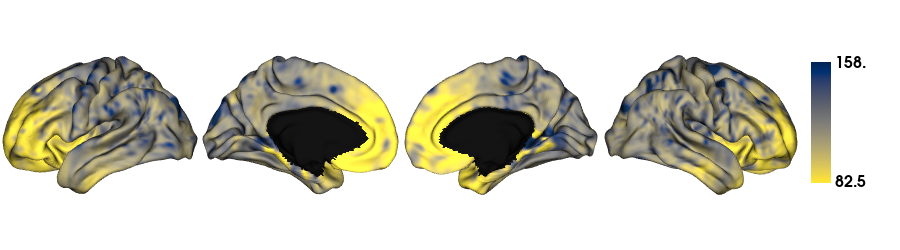

In [12]:
pfmean32k, pfmap32k = load_SWM_group_32k(surf='Parvalbumin')
# Plot average SWM surfaces
pcrange=(np.quantile(pfmean32k[mask_32k==True], 0.05), np.quantile(pfmean32k[mask_32k==True], 0.99))
plot_hemispheres(f32k_lh, f32k_rh, array_name=pfmean32k, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=pcrange)

## Plot intensities

### Bielschowsky

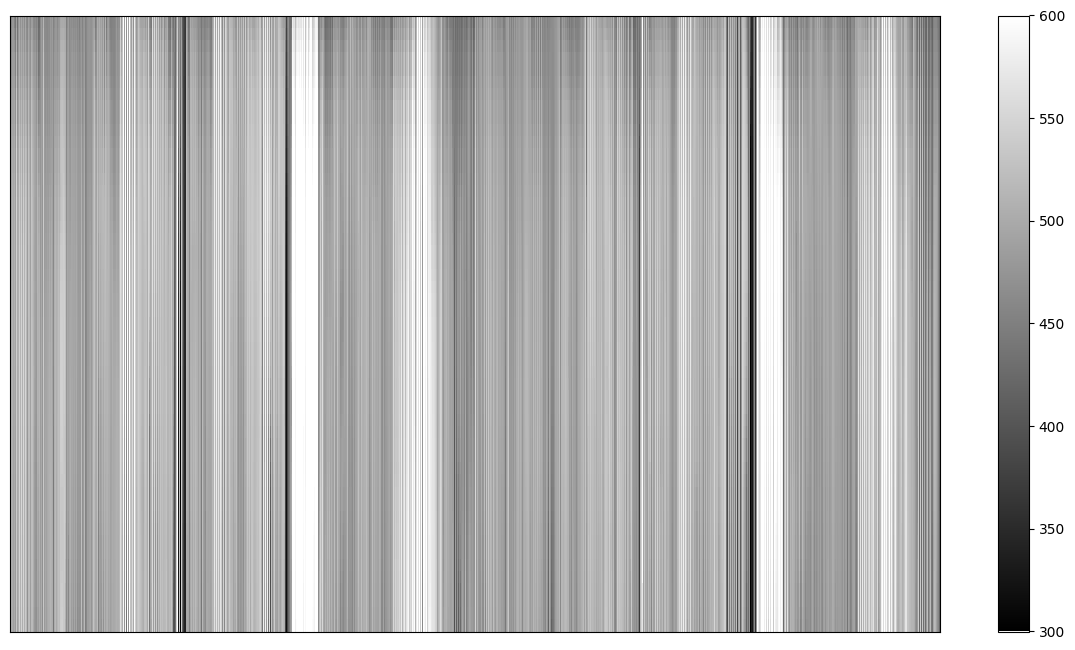

In [9]:
plot_filtered_pcolormesh(bfmap5k, mask_5k, color_range=(300, 600))

In [10]:
data_array = nb.gifti.GiftiDataArray(data=bfmap5k.astype(np.float32), intent='NIFTI_INTENT_SHAPE')
gii_img = nb.gifti.GiftiImage(darrays=[data_array])
nb.save(gii_img, '/host/verges/tank/data/youngeun/Data/for_microstructural_marketplace/sub-Ahead-Bielschowsky_surf-fsLR-5k_desc-intensity_profiles.shape.gii')

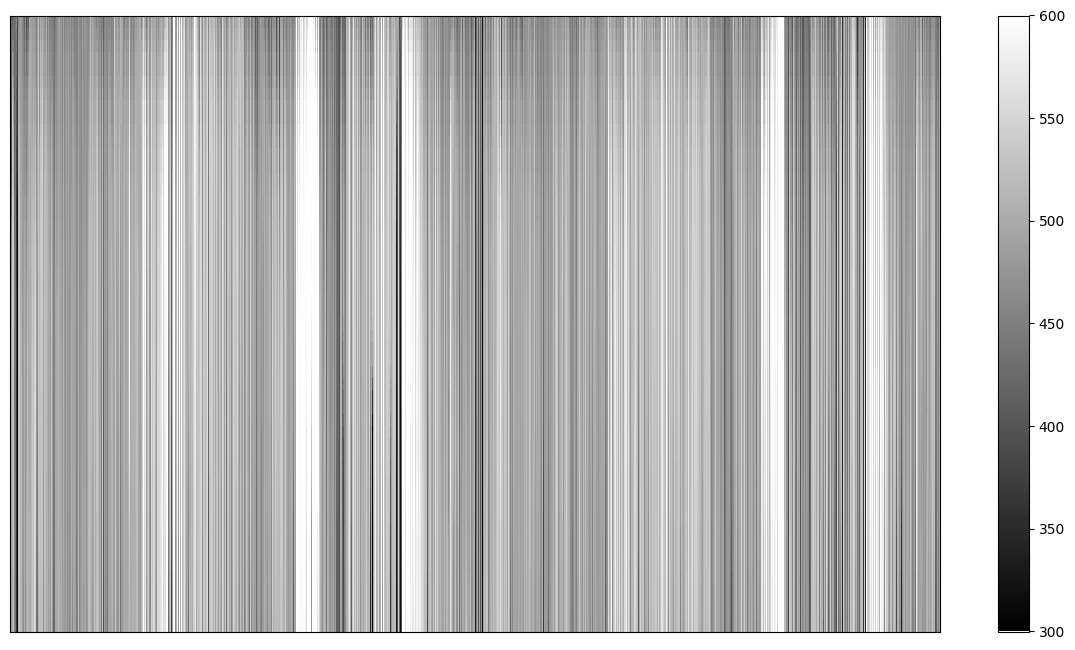

In [15]:
plot_filtered_pcolormesh(bfmap32k, mask_32k, color_range=(300, 600))

In [16]:
data_array = nb.gifti.GiftiDataArray(data=bfmap32k.astype(np.float32), intent='NIFTI_INTENT_SHAPE')
gii_img = nb.gifti.GiftiImage(darrays=[data_array])
nb.save(gii_img, '/host/verges/tank/data/youngeun/Data/for_microstructural_marketplace/sub-Ahead-Bielschowsky_surf-fsLR-32k_desc-intensity_profiles.shape.gii')

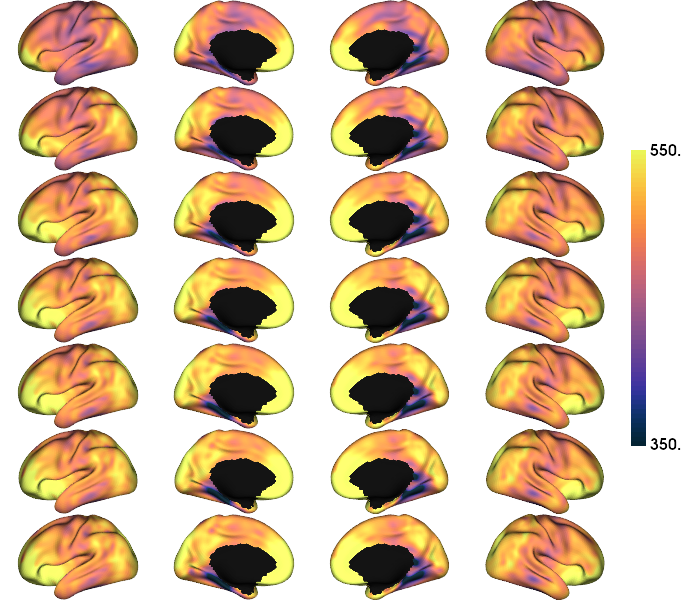

In [10]:
rows_to_extract = [0, 5, 10, 15, 20, 25, 30]
bextracted_rows = bfmap5k[rows_to_extract]

labels = [str(x)+' mm' for x in [0.00, 0.30, 0.60, 0.90, 1.20, 1.80]]
bextracted_rows[:, mask_5k == False] = np.nan

# Calculate the quantiles for the color range
map_crange=(np.quantile(bextracted_rows[:, mask_5k], 0.1), np.quantile(bextracted_rows[:, mask_5k], 1))

# Plot with the new color range
plot_hemispheres(inf_lh, inf_rh, array_name=bextracted_rows, size=(700, 600), color_bar='right', zoom=1.8, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cmo.thermal', transparent_bg=True, screenshot=False, color_range=(350,550))

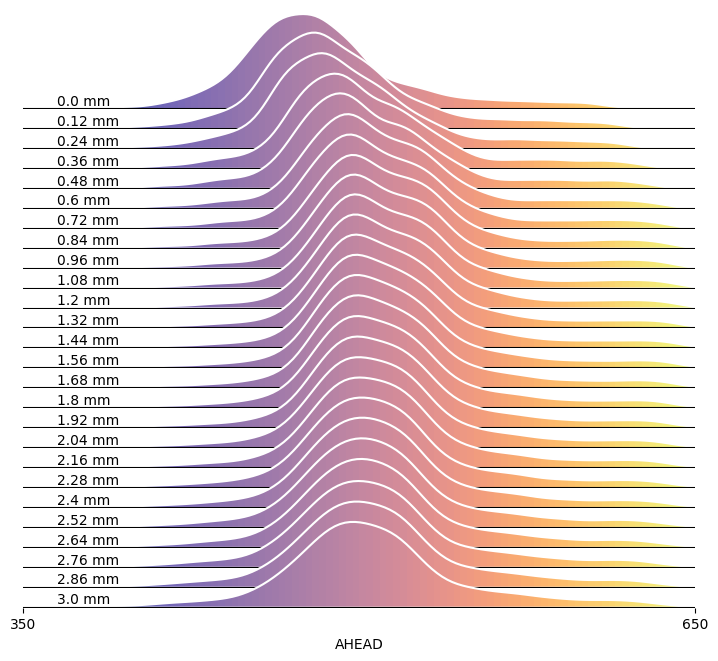

In [23]:
rows_to_extract = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
bextracted_rows = bfmap5k[rows_to_extract]

labels = [str(x)+' mm' for x in [0.00, 0.12, 0.24, 0.36, 0.48, 0.60, 0.72, 0.84, 0.96, 1.08, 1.20, 1.32, 1.44, 1.56, 1.68, 1.80, 1.92, 2.04, 2.16, 2.28, 2.40, 2.52, 2.64, 2.76, 2.86, 3.00]]
plot_img = bextracted_rows
plot_img[:, mask_5k == False] = np.nan

# Identify rows with NaN values and exclude them
valid_rows = ~np.isnan(plot_img).any(axis=0)
masked_plot_img = plot_img[:, valid_rows]

plot_ridgeplot(matrix=plot_img, matrix_df=labels, Cmap='cmo.thermal', Range=(350, 650))

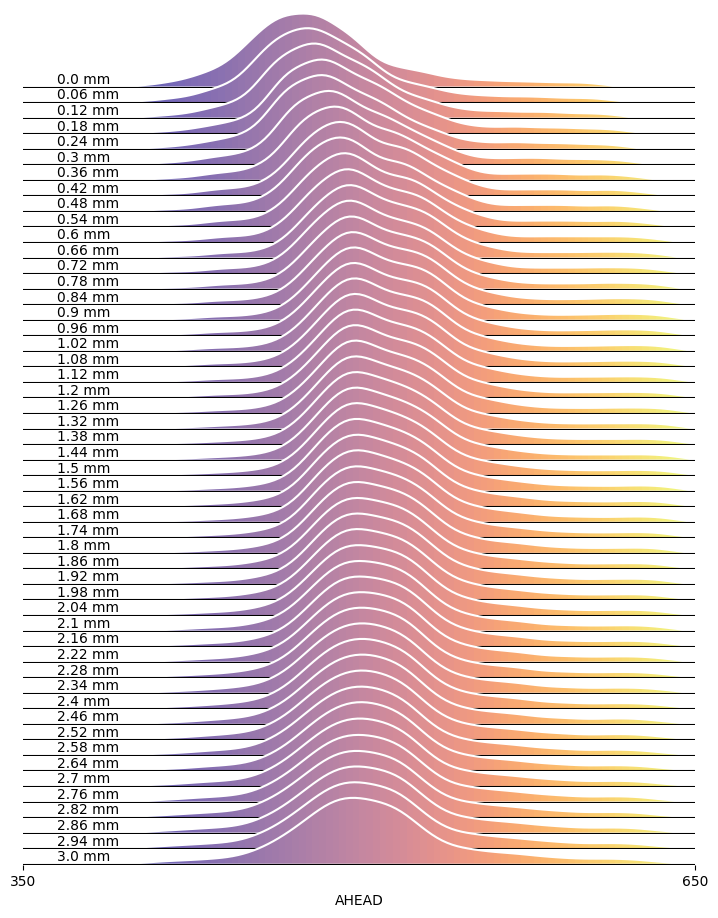

In [23]:
labels = [str(x)+' mm' for x in [0.00, 0.06, 0.12, 0.18, 0.24, 0.30, 0.36, 0.42, 0.48, 0.54, 0.60, 0.66, 0.72, 0.78, 0.84, 0.90, 0.96, 1.02, 1.08, 1.12, 1.20, 1.26, 1.32, 1.38, 1.44, 1.50, 1.56, 1.62, 1.68, 1.74, 1.80, 1.86, 1.92, 1.98, 2.04, 2.10, 2.16, 2.22, 2.28, 2.34, 2.40, 2.46, 2.52, 2.58, 2.64, 2.70, 2.76, 2.82, 2.86, 2.94, 3.00]]
plot_img = bfmap5k
plot_img[:, mask_5k == False] = np.nan

# Identify rows with NaN values and exclude them
valid_rows = ~np.isnan(plot_img).any(axis=0)
masked_plot_img = plot_img[:, valid_rows]

plot_ridgeplot(matrix=plot_img, matrix_df=labels, Cmap='cmo.thermal', Range=(350, 650))

### Parvalbumin

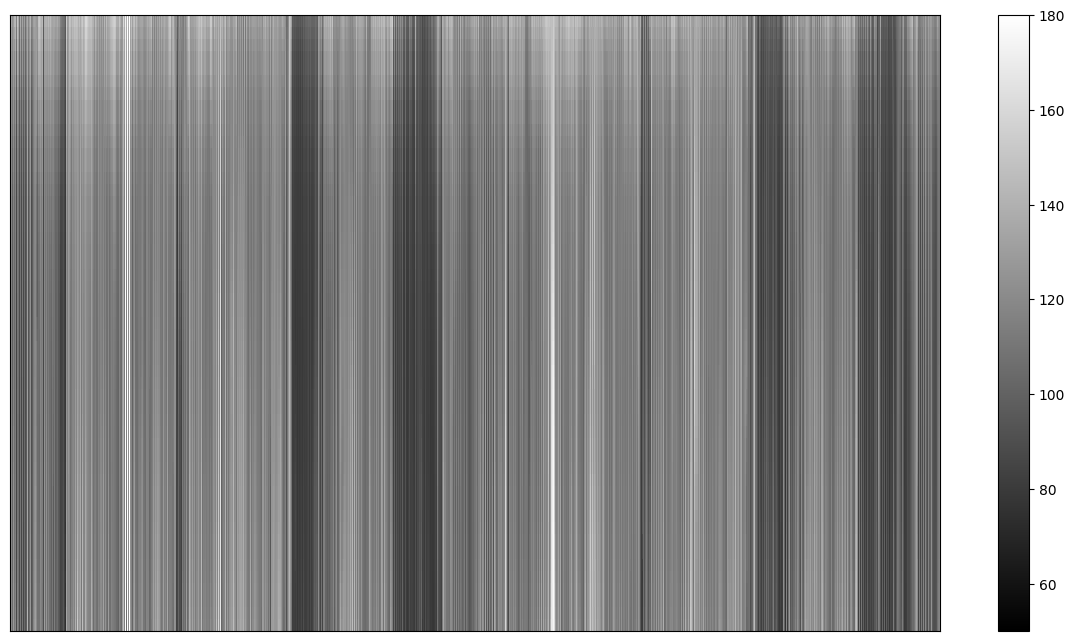

In [11]:
plot_filtered_pcolormesh(pfmap5k, mask_5k, color_range=(50, 180))

In [12]:
data_array = nb.gifti.GiftiDataArray(data=pfmap5k.astype(np.float32), intent='NIFTI_INTENT_SHAPE')
gii_img = nb.gifti.GiftiImage(darrays=[data_array])
nb.save(gii_img, '/host/verges/tank/data/youngeun/Data/for_microstructural_marketplace/sub-Ahead-Parvalbumin_surf-fsLR-5k_desc-intensity_profiles.shape.gii')

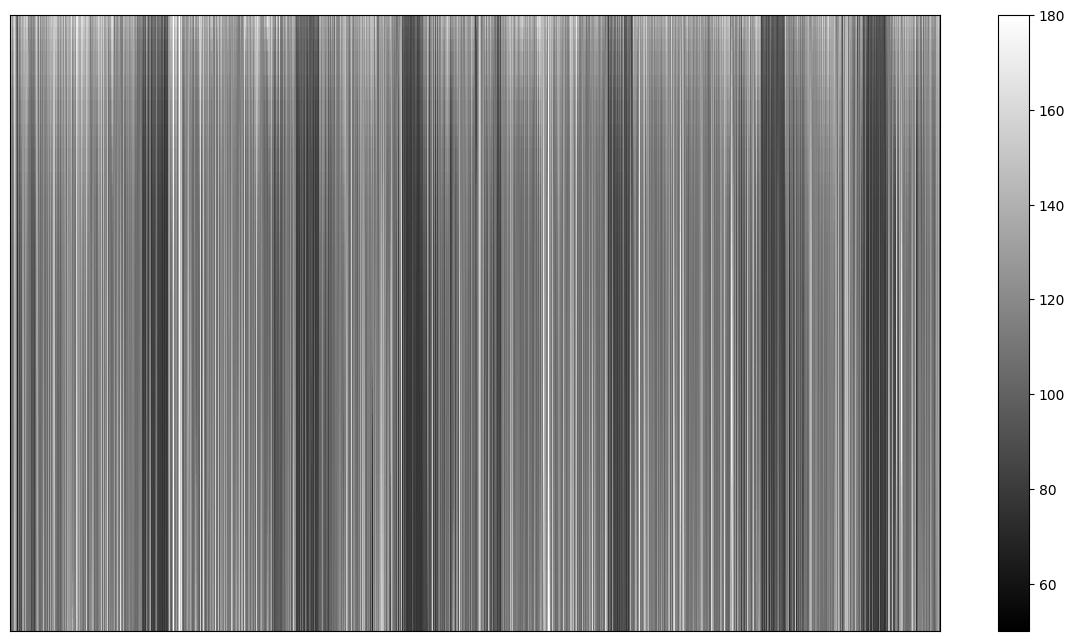

In [17]:
plot_filtered_pcolormesh(pfmap32k, mask_32k, color_range=(50, 180))

In [18]:
data_array = nb.gifti.GiftiDataArray(data=pfmap32k.astype(np.float32), intent='NIFTI_INTENT_SHAPE')
gii_img = nb.gifti.GiftiImage(darrays=[data_array])
nb.save(gii_img, '/host/verges/tank/data/youngeun/Data/for_microstructural_marketplace/sub-Ahead-Parvalbumin_surf-fsLR-32k_desc-intensity_profiles.shape.gii')

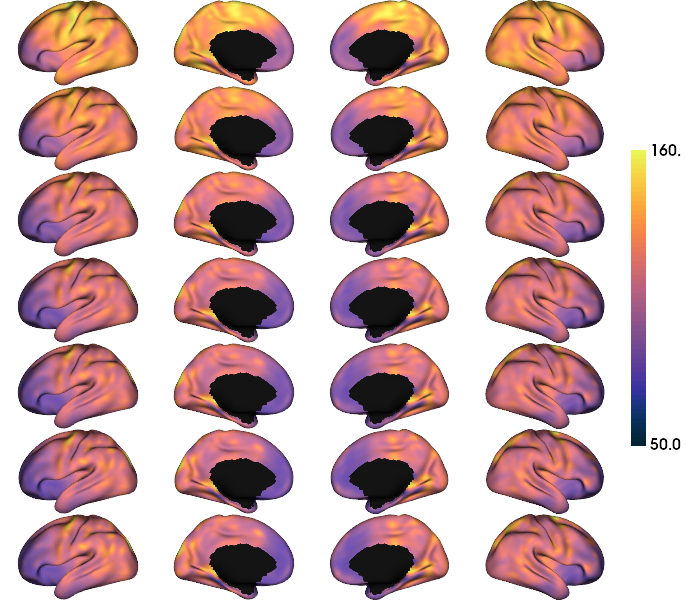

In [24]:
rows_to_extract = [0, 5, 10, 15, 20, 25, 30]
pextracted_rows = pfmap5k[rows_to_extract]

labels = [str(x)+' mm' for x in [0.00, 0.30, 0.60, 0.90, 1.20, 1.80]]
pextracted_rows[:, mask_5k == False] = np.nan

# Calculate the quantiles for the color range
map_crange=(np.quantile(pextracted_rows[:, mask_5k], 0.1), np.quantile(pextracted_rows[:, mask_5k], 1))

# Plot with the new color range
plot_hemispheres(inf_lh, inf_rh, array_name=pextracted_rows, size=(700, 600), color_bar='right', zoom=1.8, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cmo.thermal', transparent_bg=True, screenshot=False, color_range=(50,160))

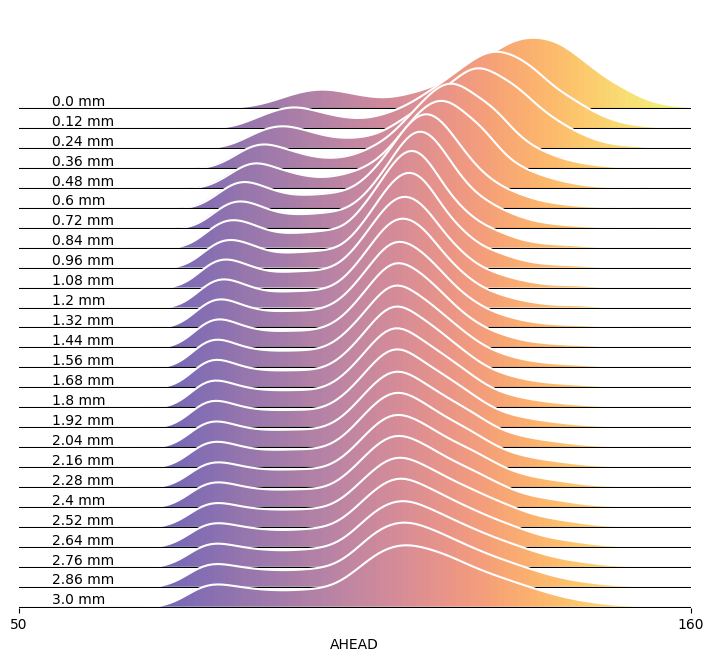

In [30]:
rows_to_extract = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
pextracted_rows = pfmap5k[rows_to_extract]

labels = [str(x)+' mm' for x in [0.00, 0.12, 0.24, 0.36, 0.48, 0.60, 0.72, 0.84, 0.96, 1.08, 1.20, 1.32, 1.44, 1.56, 1.68, 1.80, 1.92, 2.04, 2.16, 2.28, 2.40, 2.52, 2.64, 2.76, 2.86, 3.00]]
plot_img = pextracted_rows
plot_img[:, mask_5k == False] = np.nan

# Identify rows with NaN values and exclude them
valid_rows = ~np.isnan(plot_img).any(axis=0)
masked_plot_img = plot_img[:, valid_rows]

plot_ridgeplot(matrix=plot_img, matrix_df=labels, Cmap='cmo.thermal', Range=(50, 160))

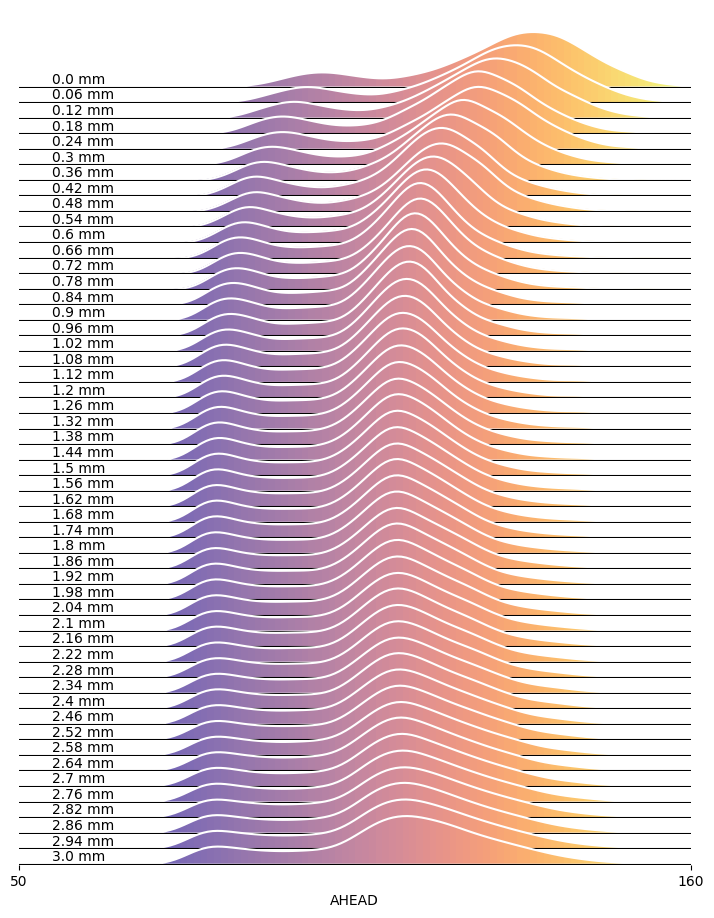

In [25]:
labels = [str(x)+' mm' for x in [0.00, 0.06, 0.12, 0.18, 0.24, 0.30, 0.36, 0.42, 0.48, 0.54, 0.60, 0.66, 0.72, 0.78, 0.84, 0.90, 0.96, 1.02, 1.08, 1.12, 1.20, 1.26, 1.32, 1.38, 1.44, 1.50, 1.56, 1.62, 1.68, 1.74, 1.80, 1.86, 1.92, 1.98, 2.04, 2.10, 2.16, 2.22, 2.28, 2.34, 2.40, 2.46, 2.52, 2.58, 2.64, 2.70, 2.76, 2.82, 2.86, 2.94, 3.00]]
plot_img = pfmap5k
plot_img[:, mask_5k == False] = np.nan

# Identify rows with NaN values and exclude them
valid_rows = ~np.isnan(plot_img).any(axis=0)
masked_plot_img = plot_img[:, valid_rows]

plot_ridgeplot(matrix=plot_img, matrix_df=labels, Cmap='cmo.thermal', Range=(50, 160))